# create the aggregated input table 

## get input features from solar.py, price.py and load.py



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from example_files.solar import get_daily_solar_kwh
from example_files.prices import get_daily_prices
from example_files.load import get_daily_load_forecast


In [2]:
# get the df for each feature in the aggregated table from date
date = "2025-03-01"

solar_kwh = get_daily_solar_kwh(date)
prices = get_daily_prices(date)
load_forecast = get_daily_load_forecast(date)

# merge the dfs on the shared time column
df = pd.merge(solar_kwh, prices, on="time")
df = pd.merge(df, load_forecast, on="time")

/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/entsoe/entsoe.py:1263: DeprecationWarning: The resolution parameter is deprecated and will be removed. This function will force the right resolution
  warnings.warn('The resolution parameter is deprecated and will be removed. This function will force the right resolution', DeprecationWarning)
/Users/joscham/.pyenv/versions/3.11.3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.2.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


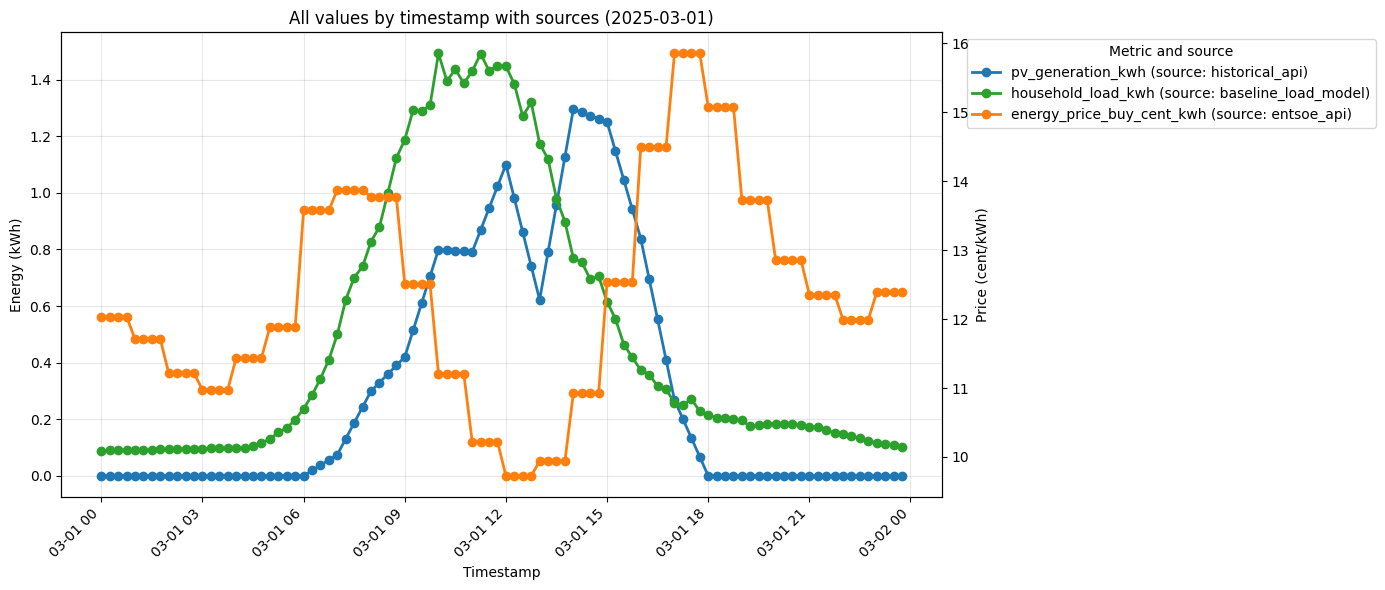

In [3]:
# keep only time, predicted_kwh_x, source_x, price_cent_kwh, source_y, predicted_kwh_y, household, and source
df_new = df[["time", "predicted_kwh_x", "source_x", "price_cent_kwh", "source_y", "predicted_kwh_y", "household", "source"]]
df_new.columns = ["utc_timestamp", "pv_generation_kwh", "source_solar", "energy_price_buy_cent_kwh", "source_price", "household_load_kwh", "household", "source_load"]

    # save the df as a csv file
df_new.to_csv("data/aggregated_table.csv", index=False)

# plot all values by timestamp with price on a second y-axis
plot_df = df_new.copy()
plot_df["utc_timestamp"] = pd.to_datetime(plot_df["utc_timestamp"])

def get_source_label(frame, source_col):
    source_values = frame[source_col].dropna().unique()
    return source_values[0] if len(source_values) > 0 else "unknown"

source_solar = get_source_label(plot_df, "source_solar")
source_price = get_source_label(plot_df, "source_price")
source_load = get_source_label(plot_df, "source_load")

fig, ax_left = plt.subplots(figsize=(14, 6))

line_solar = ax_left.plot(
    plot_df["utc_timestamp"],
    plot_df["pv_generation_kwh"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label=f"pv_generation_kwh (source: {source_solar})",
)[0]

line_load = ax_left.plot(
    plot_df["utc_timestamp"],
    plot_df["household_load_kwh"],
    marker="o",
    linewidth=2,
    color="#2ca02c",
    label=f"household_load_kwh (source: {source_load})",
)[0]

ax_left.set_xlabel("Timestamp")
ax_left.set_ylabel("Energy (kWh)")
ax_left.grid(alpha=0.3)

ax_right = ax_left.twinx()
line_price = ax_right.plot(
    plot_df["utc_timestamp"],
    plot_df["energy_price_buy_cent_kwh"],
    marker="o",
    linewidth=2,
    color="#ff7f0e",
    label=f"energy_price_buy_cent_kwh (source: {source_price})",
)[0]
ax_right.set_ylabel("Price (cent/kWh)")

lines = [line_solar, line_load, line_price]
labels = [line.get_label() for line in lines]
ax_left.legend(lines, labels, title="Metric and source", bbox_to_anchor=(1.02, 1), loc="upper left")

ax_left.set_title(f"All values by timestamp with sources ({date})")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()